<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/Early_Stopping_In_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
import seaborn as sns

In [ ]:
X,y=make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

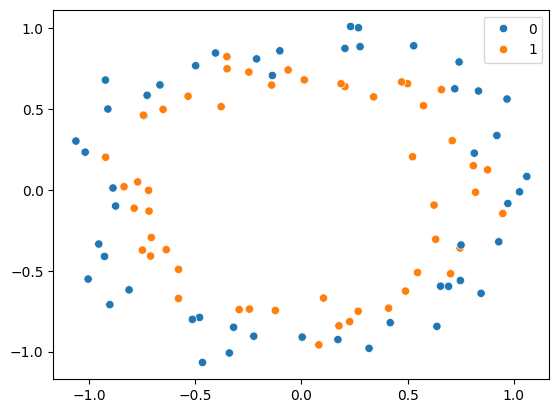

In [ ]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers import Input # Ensure Input is imported

model=Sequential()
model.add(Input(shape=(2,))) # Specify input shape explicitly
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
histroy=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,verbose=0)

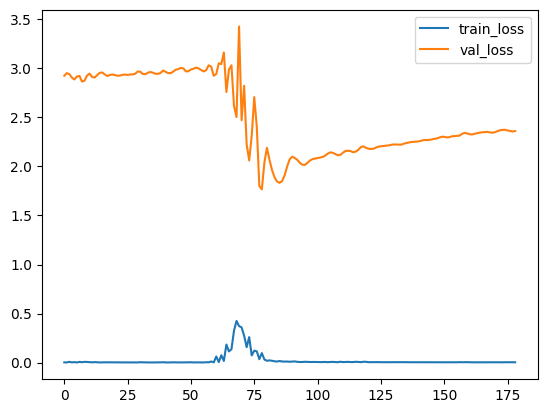

In [ ]:
plt.plot(histroy.history['loss'],label='train_loss')
plt.plot(histroy.history['val_loss'],
         label='val_loss')
plt.legend()
plt.show()

Early stopping to reduce overfitting


In [ ]:
model=Sequential()
model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
callbacks=EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=False,
    verbose=1,
    mode='auto',
    baseline=None
)

In [ ]:
histroy=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,verbose=0,callbacks=[callbacks])

Epoch 26: early stopping


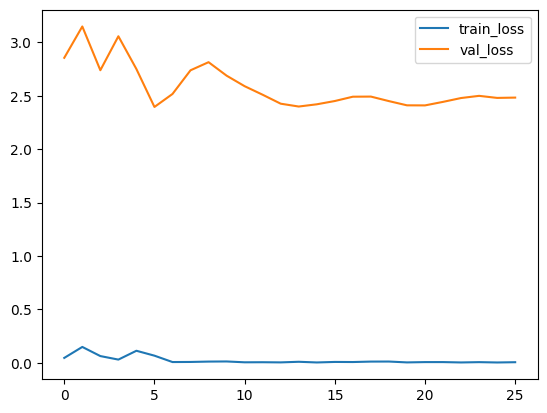

In [ ]:
plt.plot(histroy.history['loss'],label='train_loss')
plt.plot(histroy.history['val_loss'],
         label='val_loss')
plt.legend()
plt.show()